# Smart Logistics Business Analysis



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/mnt/data/smart_logistics_cleaned.csv',parse_dates=['Timestamp'])
df['Month']=df['Timestamp'].dt.month
df['Hour']=df['Timestamp'].dt.hour
df['Weekday']=df['Timestamp'].dt.day_name().str[:3]
df['Day_Type']=np.where(df['Timestamp'].dt.dayofweek<5,'Weekday','Weekend')
df['Inventory_Gap']=df['Demand_Forecast']-df['Inventory_Level']
print(df.shape)
df.head()

(1000, 24)


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay,Inventory_Status,Shift,Delay_Status,Month,Hour,Weekday,Day_Type,Inventory_Gap
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,No Reason Recorded,60.1,285,1,Sufficient Stock,Night Shift,Delayed,3,0,Wed,Weekday,-105
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1,Sufficient Stock,Day Shift,Delayed,10,7,Wed,Weekday,-317
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,No Reason Recorded,99.2,260,0,Restock Needed,Night Shift,Not Delayed,7,18,Mon,Weekday,70
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1,Sufficient Stock,Night Shift,Delayed,10,0,Mon,Weekday,-170
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,No Reason Recorded,71.6,270,1,Sufficient Stock,Day Shift,Delayed,9,15,Fri,Weekday,-210


## What is the total revenue generated by the logistics operation?

Total revenue: $299,055


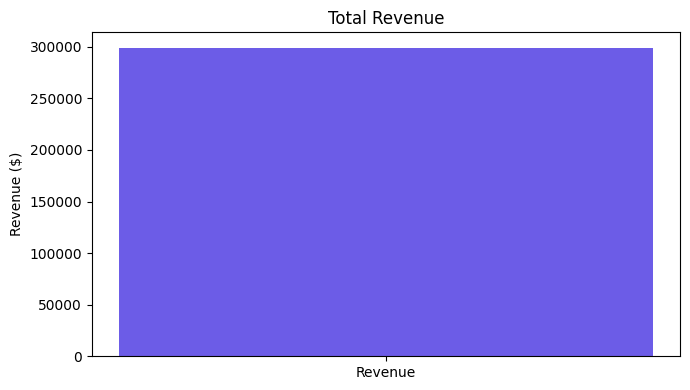

In [2]:
revenue = df['User_Transaction_Amount'].sum()
print(f'Total revenue: ${revenue:,.0f}')
plt.figure(figsize=(7,4))
plt.bar(['Revenue'], [revenue], color='#6C5CE7')
plt.ylabel('Revenue ($)')
plt.title('Total Revenue')
plt.tight_layout()

**Insight:** The operation generates $299,055 across 1,000 trips.

**Business Improvement:** Protect revenue by reducing delays and service failures on revenue-generating trips.

## How does revenue change month by month?

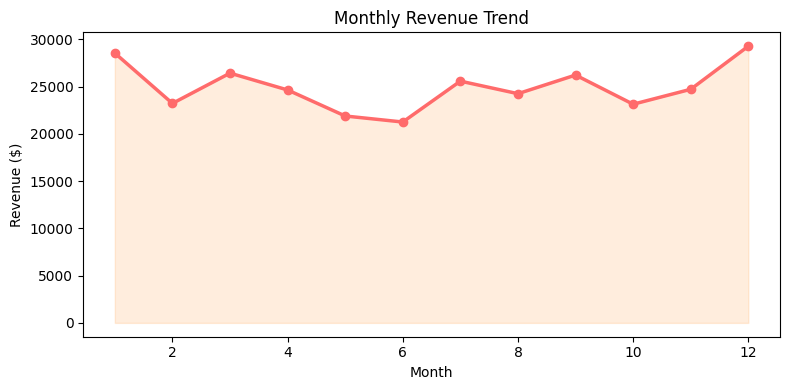

In [3]:
monthly_revenue = df.groupby('Month')['User_Transaction_Amount'].sum()
plt.figure(figsize=(8,4))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='#FF6B6B', linewidth=2.5)
plt.fill_between(monthly_revenue.index, monthly_revenue.values, alpha=.18, color='#FF9F43')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.title('Monthly Revenue Trend')
plt.tight_layout()

**Insight:** Revenue peaks in month 12 at $29,268 and is lowest in month 6 at $21,245.

**Business Improvement:** Investigate weak months and move capacity, promotions, and route focus toward those periods.

## Which shipment status contributes the most revenue?

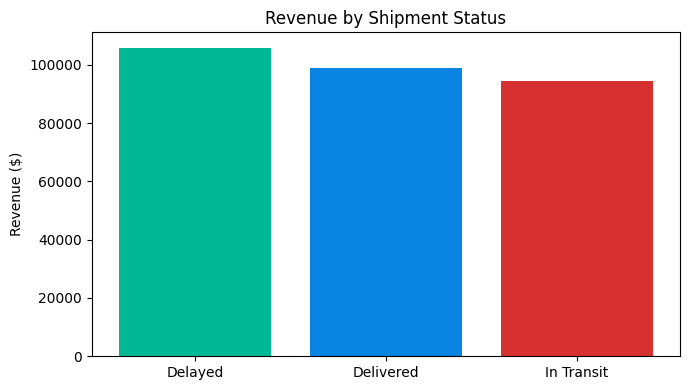

In [4]:
x = df.groupby('Shipment_Status')['User_Transaction_Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(7,4))
plt.bar(x.index, x.values, color=['#00B894','#0984E3','#D63031'])
plt.ylabel('Revenue ($)')
plt.title('Revenue by Shipment Status')
plt.tight_layout()

**Insight:** Delayed contributes the most revenue at $105,877.

**Business Improvement:** Improve completion and recovery of revenue tied to delayed or in-transit shipments.

## Which asset generates the most revenue?

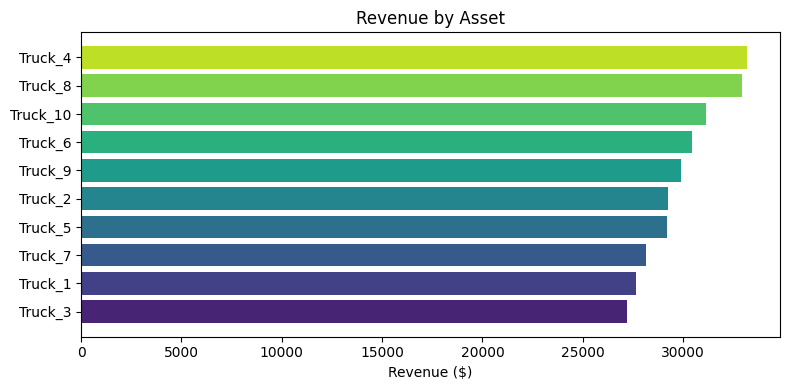

In [5]:
x = df.groupby('Asset_ID')['User_Transaction_Amount'].sum().sort_values()
plt.figure(figsize=(8,4))
plt.barh(x.index, x.values, color=plt.cm.viridis(np.linspace(.1,.9,len(x))))
plt.xlabel('Revenue ($)')
plt.title('Revenue by Asset')
plt.tight_layout()

**Insight:** Truck_4 generates the highest revenue at $33,168.

**Business Improvement:** Protect high-revenue assets with preventive maintenance and priority scheduling.

## Which assets have the highest delay rate?

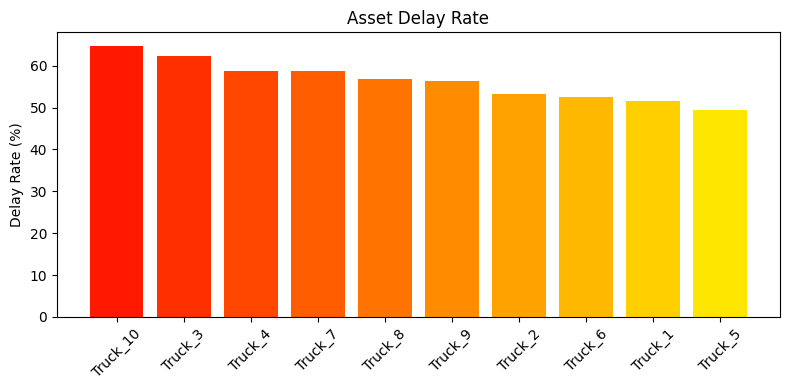

In [6]:
x = df.groupby('Asset_ID')['Logistics_Delay'].mean().sort_values(ascending=False)*100
plt.figure(figsize=(8,4))
plt.bar(x.index, x.values, color=plt.cm.autumn(np.linspace(.1,.9,len(x))))
plt.ylabel('Delay Rate (%)')
plt.title('Asset Delay Rate')
plt.xticks(rotation=45)
plt.tight_layout()

**Insight:** Truck_10 has the highest delay rate at 64.8%.

**Business Improvement:** Inspect high-delay assets first and rebalance their workload.

## Which assets have the highest utilization?

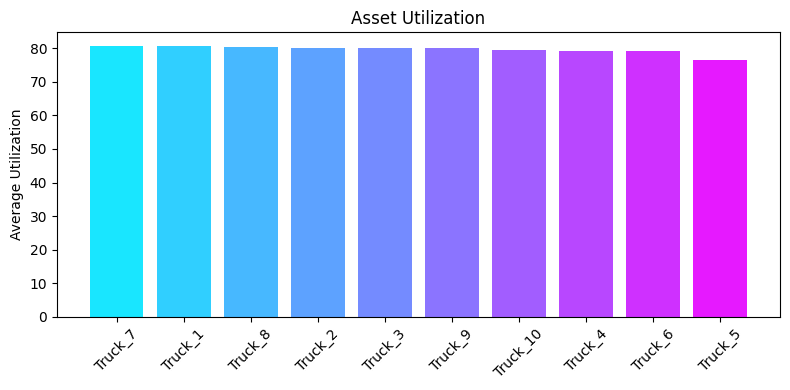

In [7]:
x = df.groupby('Asset_ID')['Asset_Utilization'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.bar(x.index, x.values, color=plt.cm.cool(np.linspace(.1,.9,len(x))))
plt.ylabel('Average Utilization')
plt.title('Asset Utilization')
plt.xticks(rotation=45)
plt.tight_layout()

**Insight:** Truck_7 has the highest utilization at 80.67.

**Business Improvement:** Keep high performers productive but schedule maintenance before utilization becomes a bottleneck.

## Which traffic condition creates the most delays?

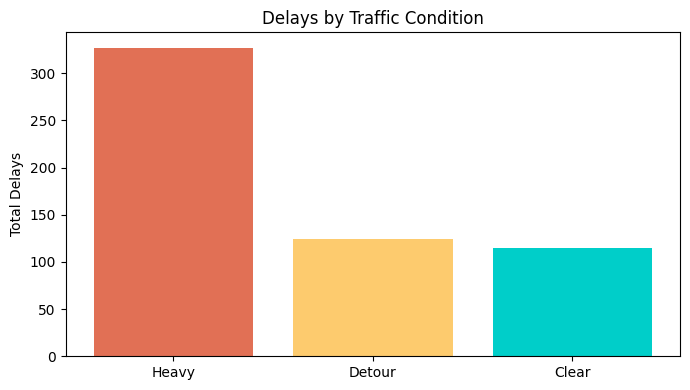

In [8]:
x = df.groupby('Traffic_Status')['Logistics_Delay'].sum().sort_values(ascending=False)
plt.figure(figsize=(7,4))
plt.bar(x.index, x.values, color=['#E17055','#FDCB6E','#00CEC9'])
plt.ylabel('Total Delays')
plt.title('Delays by Traffic Condition')
plt.tight_layout()

**Insight:** Heavy produces the most delays with 327 incidents.

**Business Improvement:** Use traffic-aware routing and earlier dispatch buffers under the highest-risk condition.

## What is the shipment status mix?

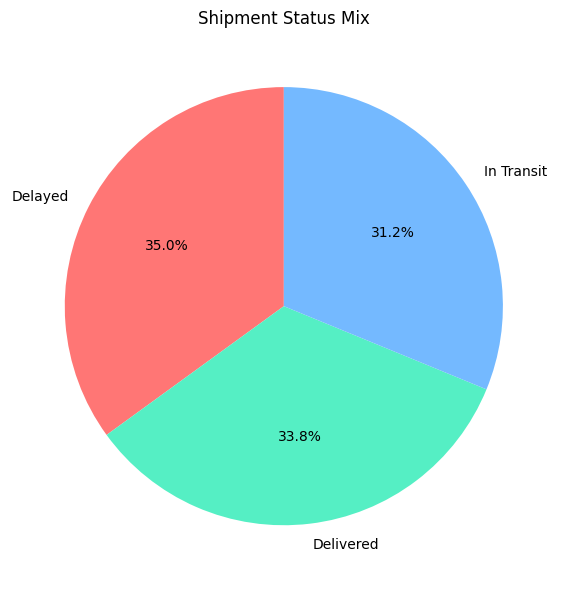

In [9]:
x = df['Shipment_Status'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(x.values, labels=x.index, autopct='%1.1f%%', colors=['#FF7675','#55EFC4','#74B9FF'], startangle=90)
plt.title('Shipment Status Mix')
plt.tight_layout()

**Insight:** Delayed shipments represent 35.0% of all trips.

**Business Improvement:** Reduce the delayed share with exception alerts and faster recovery actions.

## Which delay reason has the highest revenue exposure?

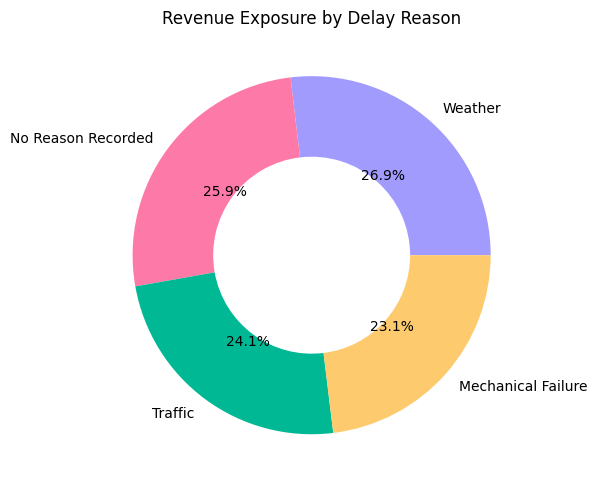

In [10]:
x = df.groupby('Logistics_Delay_Reason')['User_Transaction_Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(6,6))
plt.pie(x.values, labels=x.index, autopct='%1.1f%%', colors=['#A29BFE','#FD79A8','#00B894','#FDCB6E'], wedgeprops={'width':.45})
plt.title('Revenue Exposure by Delay Reason')
plt.tight_layout()

**Insight:** Weather is linked to the largest revenue exposure at $80,389.

**Business Improvement:** Prioritize prevention where delay exposure can protect the most revenue.

## Which traffic condition has the longest average waiting time?

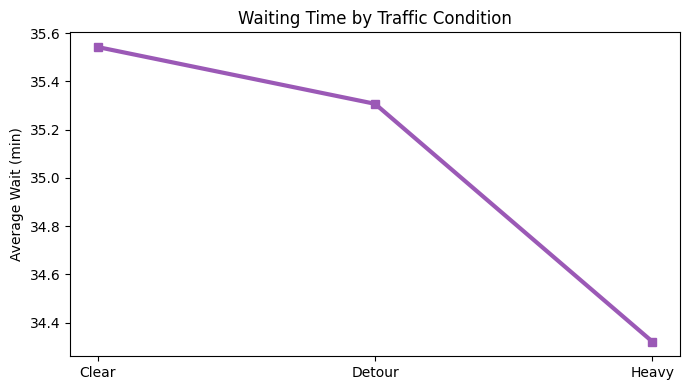

In [11]:
x = df.groupby('Traffic_Status')['Waiting_Time'].mean().sort_values(ascending=False)
plt.figure(figsize=(7,4))
plt.plot(x.index, x.values, marker='s', linewidth=3, color='#9B59B6')
plt.ylabel('Average Wait (min)')
plt.title('Waiting Time by Traffic Condition')
plt.tight_layout()

**Insight:** Clear has the longest average wait at 35.54 minutes.

**Business Improvement:** Add route buffers and dispatch changes for the condition with the longest wait.

## Does a longer wait increase delay risk?

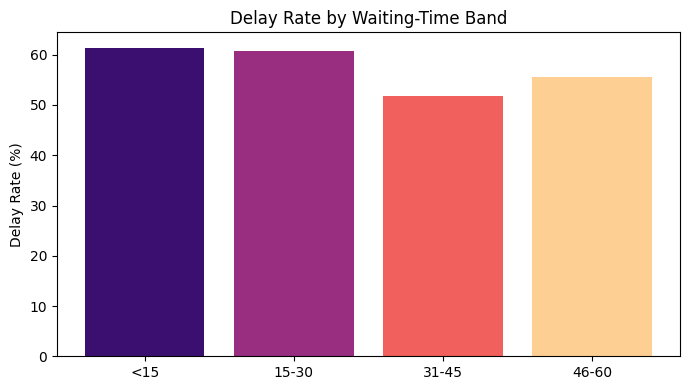

In [12]:
bands = pd.cut(df['Waiting_Time'], [0,15,30,45,60], labels=['<15','15-30','31-45','46-60'])
x = df.groupby(bands, observed=False)['Logistics_Delay'].mean()*100
plt.figure(figsize=(7,4))
plt.bar(x.index.astype(str), x.values, color=plt.cm.magma(np.linspace(.2,.9,len(x))))
plt.ylabel('Delay Rate (%)')
plt.title('Delay Rate by Waiting-Time Band')
plt.tight_layout()

**Insight:** The highest waiting band has a delay rate of 61.4%.

**Business Improvement:** Set escalation triggers for long waits before they become delivery delays.

## Which shipment status has the longest wait?

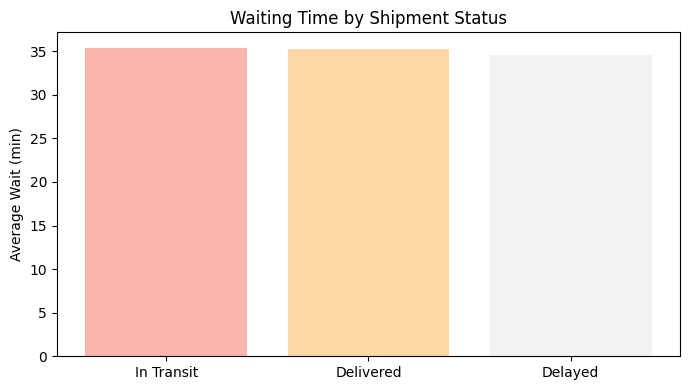

In [13]:
x = df.groupby('Shipment_Status')['Waiting_Time'].mean().sort_values(ascending=False)
plt.figure(figsize=(7,4))
plt.bar(x.index, x.values, color=plt.cm.Pastel1(np.linspace(.05,.9,len(x))))
plt.ylabel('Average Wait (min)')
plt.title('Waiting Time by Shipment Status')
plt.tight_layout()

**Insight:** In Transit has the longest average wait at 35.39 minutes.

**Business Improvement:** Focus operational support on the slowest shipment stage.

## Which month has the most delays?

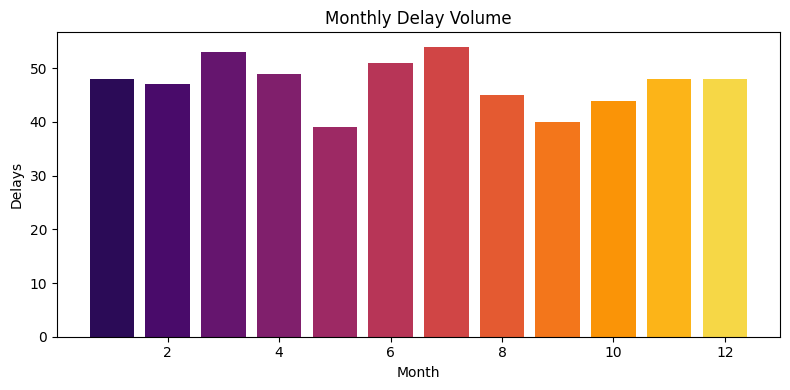

In [14]:
x = df.groupby('Month')['Logistics_Delay'].sum()
plt.figure(figsize=(8,4))
plt.bar(x.index, x.values, color=plt.cm.inferno(np.linspace(.15,.9,12)))
plt.xlabel('Month')
plt.ylabel('Delays')
plt.title('Monthly Delay Volume')
plt.tight_layout()

**Insight:** Month 7 has the highest delay volume with 54 delays.

**Business Improvement:** Add capacity, route buffers, and maintenance coverage before peak-delay months.

## Which month has the best revenue per trip?

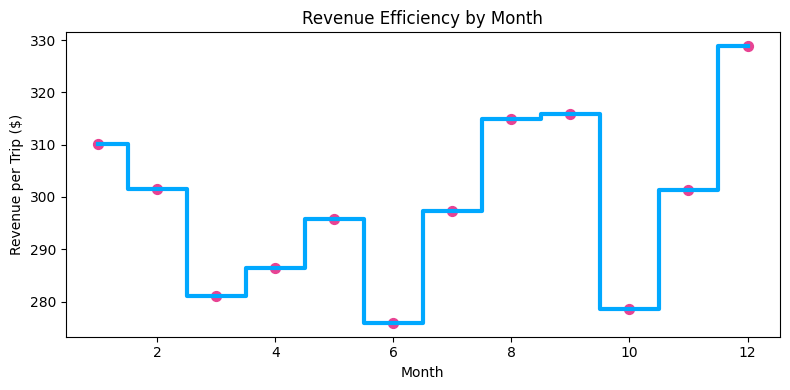

In [15]:
x = df.groupby('Month').agg(revenue=('User_Transaction_Amount','sum'), trips=('Asset_ID','size'))
x['Revenue_Per_Trip'] = x['revenue']/x['trips']
plt.figure(figsize=(8,4))
plt.step(x.index, x['Revenue_Per_Trip'], where='mid', color='#00A8FF', linewidth=3)
plt.scatter(x.index, x['Revenue_Per_Trip'], color='#E84393', s=50)
plt.xlabel('Month')
plt.ylabel('Revenue per Trip ($)')
plt.title('Revenue Efficiency by Month')
plt.tight_layout()

**Insight:** Month 12 has the best revenue per trip at $328.85.

**Business Improvement:** Identify the demand mix and operating conditions that made the strongest month more productive.

## Which day of week has the most delays?

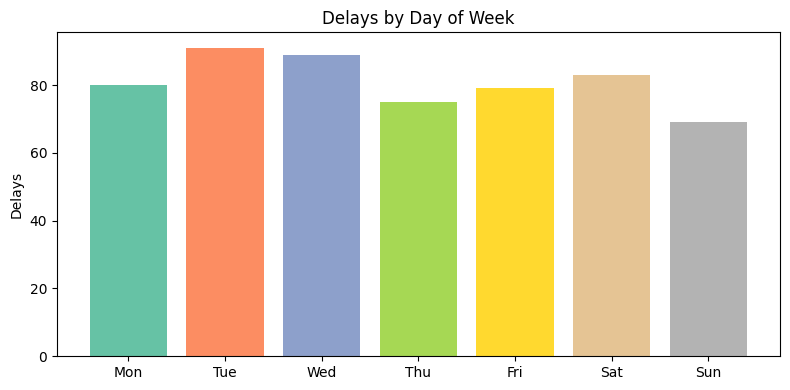

In [16]:
order=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
x=df.groupby('Weekday')['Logistics_Delay'].sum().reindex(order)
plt.figure(figsize=(8,4))
plt.bar(x.index,x.values,color=plt.cm.Set2(np.linspace(0,1,7)))
plt.ylabel('Delays')
plt.title('Delays by Day of Week')
plt.tight_layout()

**Insight:** Tue has the highest delay count.

**Business Improvement:** Increase monitoring and dispatch readiness on the highest-delay day.

## Are weekdays or weekends more delay-prone?

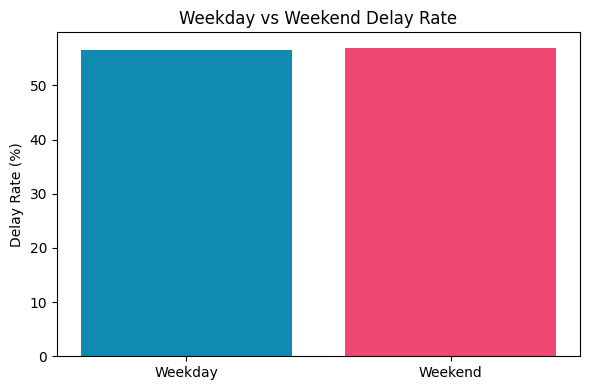

In [17]:
x=df.groupby('Day_Type')['Logistics_Delay'].mean()*100
plt.figure(figsize=(6,4))
plt.bar(x.index,x.values,color=['#118AB2','#EF476F'])
plt.ylabel('Delay Rate (%)')
plt.title('Weekday vs Weekend Delay Rate')
plt.tight_layout()

**Insight:** Weekend has the higher delay rate at 56.9%.

**Business Improvement:** Match staffing and route coverage to the higher-risk day type.

## Which shift generates more revenue?

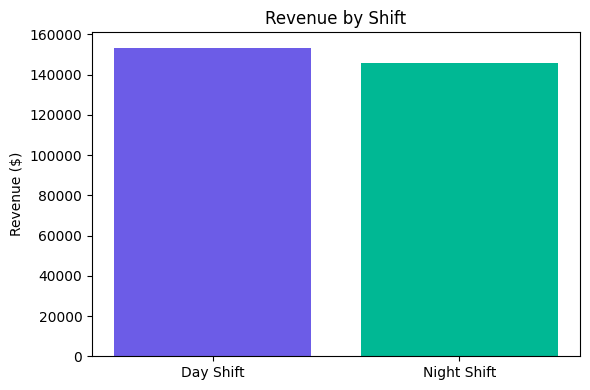

In [18]:
x=df.groupby('Shift')['User_Transaction_Amount'].sum()
plt.figure(figsize=(6,4))
plt.bar(x.index,x.values,color=['#6C5CE7','#00B894'])
plt.ylabel('Revenue ($)')
plt.title('Revenue by Shift')
plt.tight_layout()

**Insight:** Day Shift generates more revenue at $153,289.

**Business Improvement:** Protect the stronger shift while improving the weaker shift's capacity and service quality.

## Which shift has the higher delay rate?

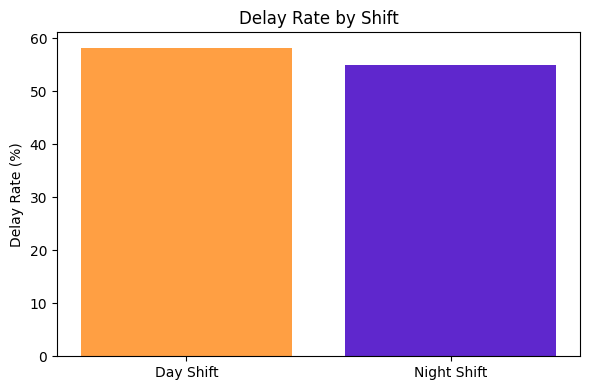

In [19]:
x=df.groupby('Shift')['Logistics_Delay'].mean()*100
plt.figure(figsize=(6,4))
plt.bar(x.index,x.values,color=['#FF9F43','#5F27CD'])
plt.ylabel('Delay Rate (%)')
plt.title('Delay Rate by Shift')
plt.tight_layout()

**Insight:** Day Shift has the higher delay rate at 58.2%.

**Business Improvement:** Review staffing, route conditions, and asset assignment on the higher-delay shift.

## Which shift has higher asset utilization?

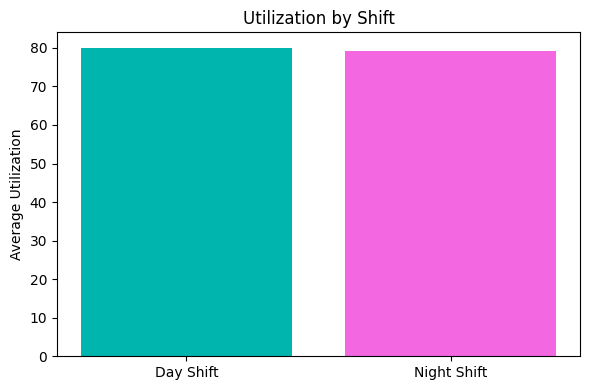

In [20]:
x=df.groupby('Shift')['Asset_Utilization'].mean()
plt.figure(figsize=(6,4))
plt.bar(x.index,x.values,color=['#00B5AD','#F368E0'])
plt.ylabel('Average Utilization')
plt.title('Utilization by Shift')
plt.tight_layout()

**Insight:** Day Shift has the higher utilization at 80.02.

**Business Improvement:** Balance asset assignments so productive capacity is not concentrated in one shift.

## Which customer purchase frequency generates the most revenue?

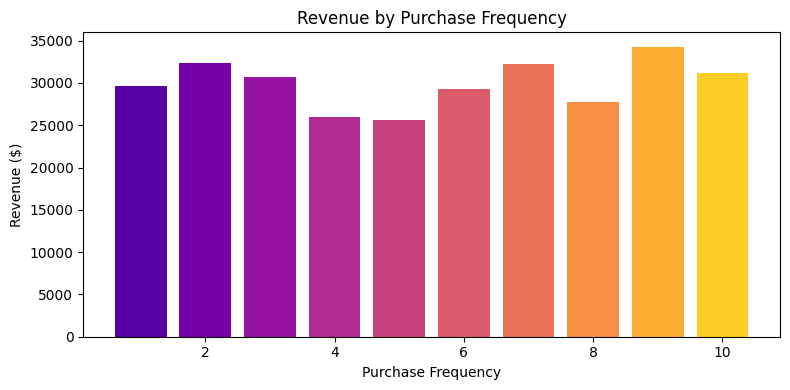

In [21]:
x=df.groupby('User_Purchase_Frequency')['User_Transaction_Amount'].sum()
plt.figure(figsize=(8,4))
plt.bar(x.index,x.values,color=plt.cm.plasma(np.linspace(.15,.9,len(x))))
plt.xlabel('Purchase Frequency')
plt.ylabel('Revenue ($)')
plt.title('Revenue by Purchase Frequency')
plt.tight_layout()

**Insight:** Frequency 9 generates the highest revenue at $34,268.

**Business Improvement:** Build retention and priority-service programs around the highest-value frequency segment.

## Does purchase frequency increase average transaction value?

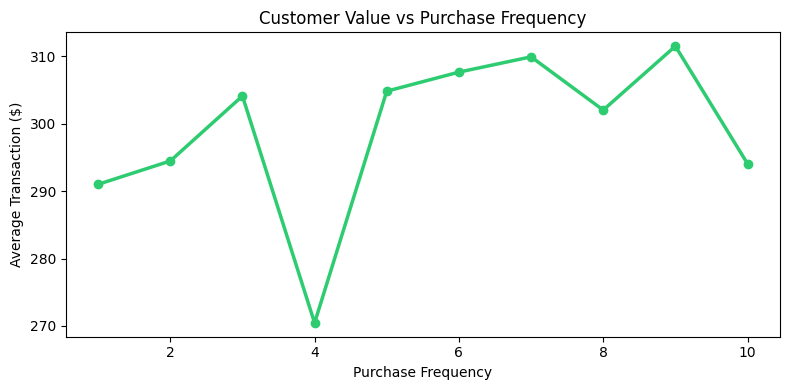

In [22]:
x=df.groupby('User_Purchase_Frequency')['User_Transaction_Amount'].mean()
plt.figure(figsize=(8,4))
plt.plot(x.index,x.values,marker='o',color='#2ECC71',linewidth=2.5)
plt.xlabel('Purchase Frequency')
plt.ylabel('Average Transaction ($)')
plt.title('Customer Value vs Purchase Frequency')
plt.tight_layout()

**Insight:** Average transaction value peaks at frequency 9 with $311.53; the trend is not strictly increasing.

**Business Improvement:** Combine frequency and transaction value when defining customer priorities.

## Which frequency group has the most delayed trips?

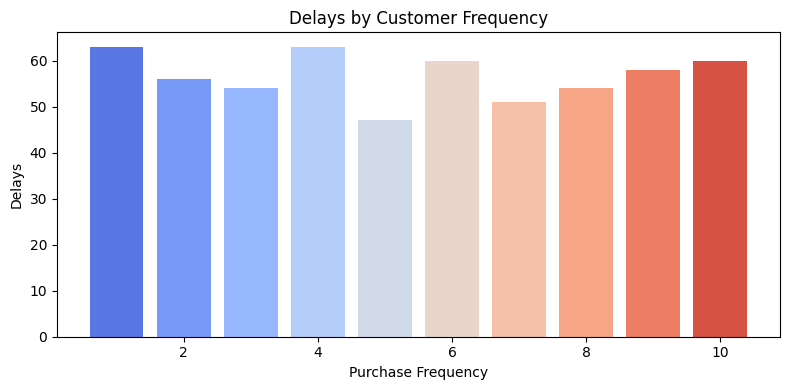

In [23]:
x=df.groupby('User_Purchase_Frequency')['Logistics_Delay'].sum()
plt.figure(figsize=(8,4))
plt.bar(x.index,x.values,color=plt.cm.coolwarm(np.linspace(.1,.9,len(x))))
plt.xlabel('Purchase Frequency')
plt.ylabel('Delays')
plt.title('Delays by Customer Frequency')
plt.tight_layout()

**Insight:** Frequency 1 has the most delayed trips with 63.

**Business Improvement:** Give frequent customers proactive delay alerts and faster recovery support.

## Do frequent customers face longer waits?

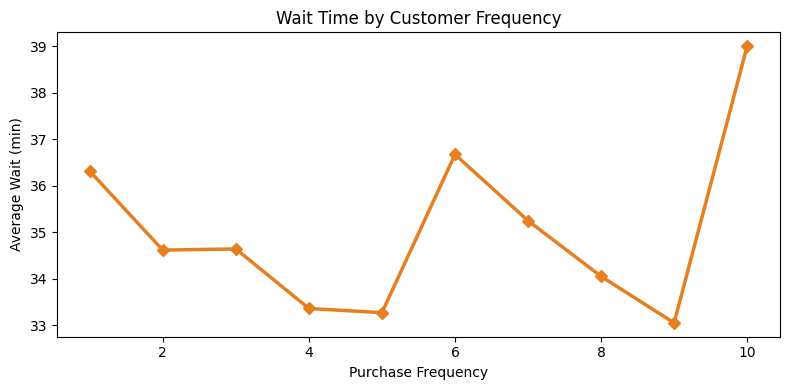

In [24]:
x=df.groupby('User_Purchase_Frequency')['Waiting_Time'].mean()
plt.figure(figsize=(8,4))
plt.plot(x.index,x.values,marker='D',color='#E67E22',linewidth=2.5)
plt.xlabel('Purchase Frequency')
plt.ylabel('Average Wait (min)')
plt.title('Wait Time by Customer Frequency')
plt.tight_layout()

**Insight:** Frequency 10 has the highest average wait at 39.00 minutes.

**Business Improvement:** Set service alerts for high-frequency customers when waits exceed the operating norm.

## Which assets create the most delays for priority customers?

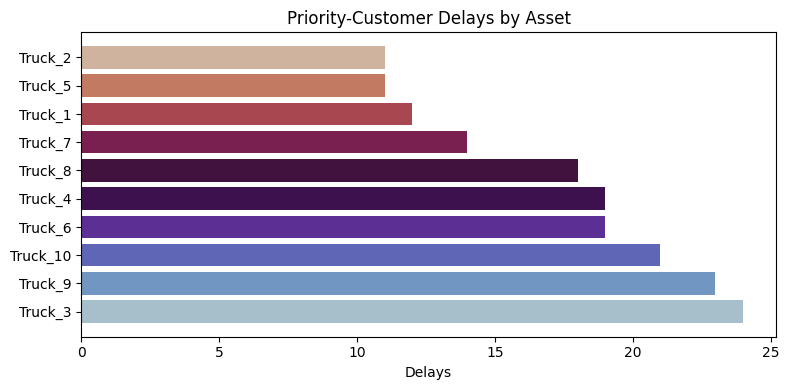

In [25]:
x=df[df['User_Purchase_Frequency']>=8].groupby('Asset_ID')['Logistics_Delay'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.barh(x.index,x.values,color=plt.cm.twilight(np.linspace(.1,.9,len(x))))
plt.xlabel('Delays')
plt.title('Priority-Customer Delays by Asset')
plt.tight_layout()

**Insight:** Truck_3 creates the most delays for frequency-8+ customers.

**Business Improvement:** Assign reliable assets to priority customers and inspect recurring problem assets.

## What is the distribution of transaction values?

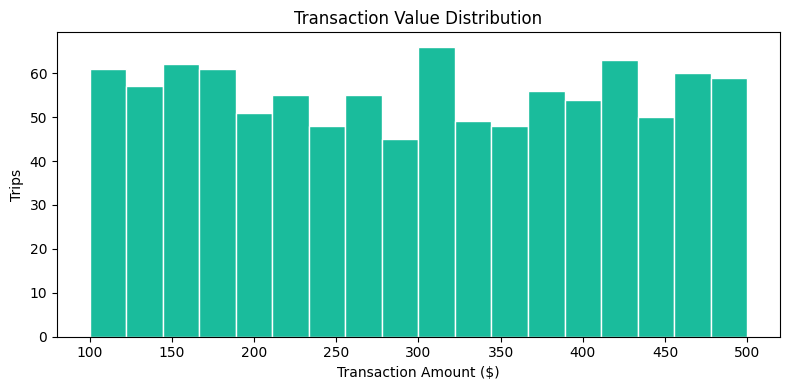

In [26]:
plt.figure(figsize=(8,4))
plt.hist(df['User_Transaction_Amount'],bins=18,color='#1ABC9C',edgecolor='white')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Trips')
plt.title('Transaction Value Distribution')
plt.tight_layout()

**Insight:** Transaction values range from $100 to $500, with a median of $302.

**Business Improvement:** Use value bands to set different service priorities and exception rules.

## What is the transaction-value density?

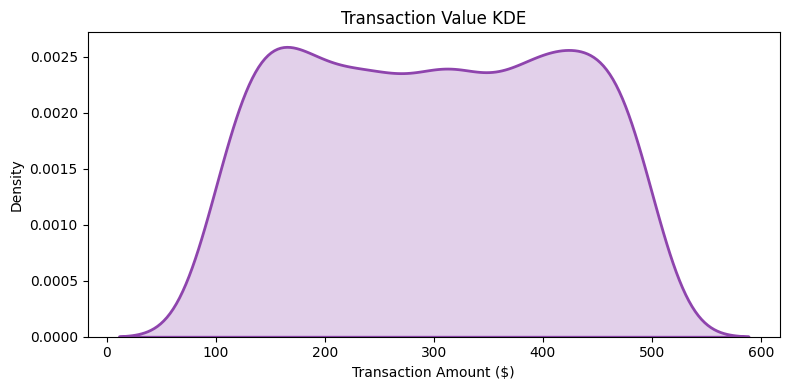

In [27]:
plt.figure(figsize=(8,4))
sns.kdeplot(df['User_Transaction_Amount'],fill=True,color='#8E44AD',linewidth=2)
plt.xlabel('Transaction Amount ($)')
plt.title('Transaction Value KDE')
plt.tight_layout()

**Insight:** Transaction values are broadly concentrated around the middle of the range rather than only at the extremes.

**Business Improvement:** Build customer tiers from the full value distribution.

## How variable is waiting time by shipment status?

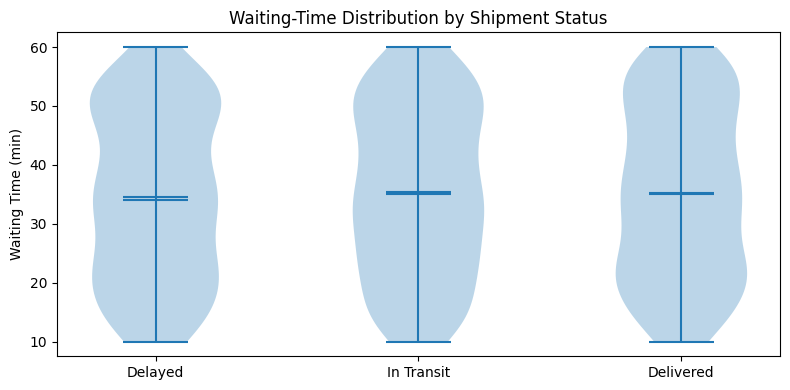

In [28]:
groups=[df.loc[df['Shipment_Status']==x,'Waiting_Time'] for x in df['Shipment_Status'].unique()]
plt.figure(figsize=(8,4))
plt.violinplot(groups,showmeans=True,showmedians=True)
plt.xticks(range(1,4),df['Shipment_Status'].unique())
plt.ylabel('Waiting Time (min)')
plt.title('Waiting-Time Distribution by Shipment Status')
plt.tight_layout()

**Insight:** The violin distributions show meaningful variation in wait times across shipment stages.

**Business Improvement:** Standardize handling at the most variable shipment stage and investigate exceptions.

## What is the spread of waiting time on delayed trips?

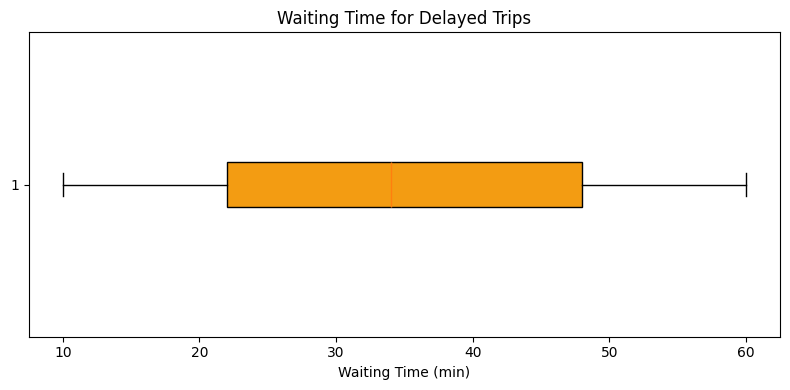

In [29]:
x=df.loc[df['Logistics_Delay']==1,'Waiting_Time']
plt.figure(figsize=(8,4))
plt.boxplot(x,vert=False,patch_artist=True,boxprops={'facecolor':'#F39C12'})
plt.xlabel('Waiting Time (min)')
plt.title('Waiting Time for Delayed Trips')
plt.tight_layout()

**Insight:** Delayed trips have a median wait of 34.0 minutes.

**Business Improvement:** Use the upper wait range as an escalation threshold for dispatch teams.

## Is asset utilization related to waiting time?

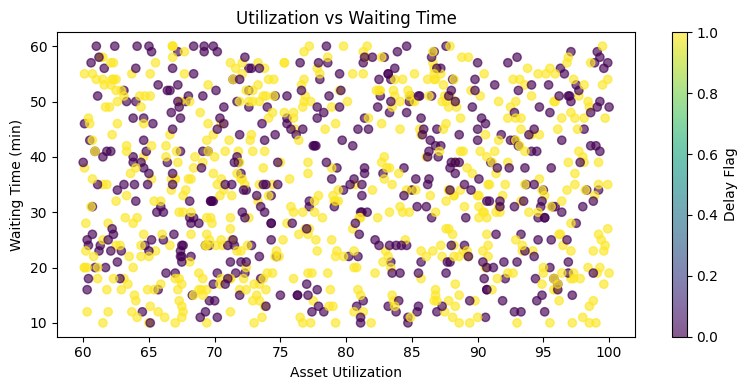

In [30]:
plt.figure(figsize=(8,4))
plt.scatter(df['Asset_Utilization'],df['Waiting_Time'],c=df['Logistics_Delay'],cmap='viridis',alpha=.65)
plt.xlabel('Asset Utilization')
plt.ylabel('Waiting Time (min)')
plt.title('Utilization vs Waiting Time')
plt.colorbar(label='Delay Flag')
plt.tight_layout()

**Insight:** Utilization and waiting time show no strong linear relationship in this dataset.

**Business Improvement:** Target specific high-utilization/high-wait assets instead of reducing utilization across the fleet.

## Is transaction value related to purchase frequency?

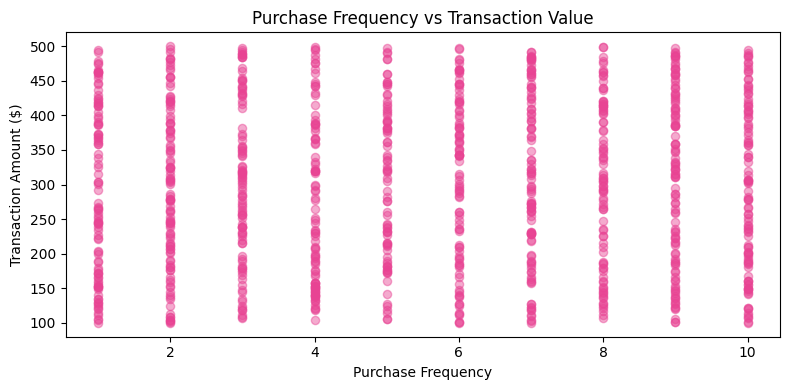

In [31]:
plt.figure(figsize=(8,4))
plt.scatter(df['User_Purchase_Frequency'],df['User_Transaction_Amount'],s=35,alpha=.45,color='#E84393')
plt.xlabel('Purchase Frequency')
plt.ylabel('Transaction Amount ($)')
plt.title('Purchase Frequency vs Transaction Value')
plt.tight_layout()

**Insight:** Purchase frequency has only a weak relationship with transaction value.

**Business Improvement:** Combine frequency and transaction value when setting customer service tiers.

## How large is the restock-needed segment?

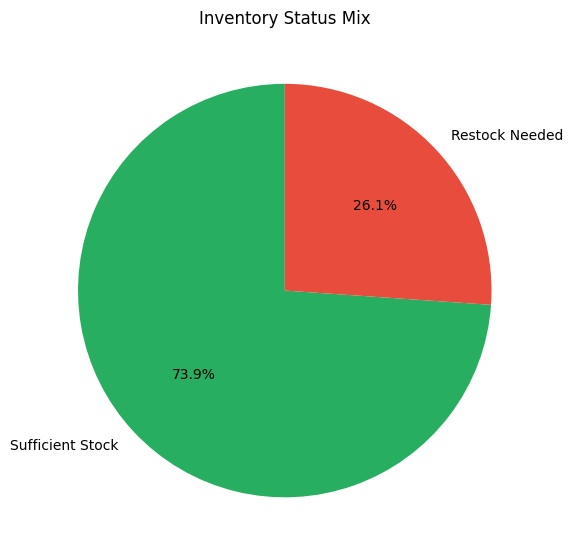

In [32]:
x=df['Inventory_Status'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(x.values,labels=x.index,autopct='%1.1f%%',colors=['#27AE60','#E74C3C'],startangle=90)
plt.title('Inventory Status Mix')
plt.tight_layout()

**Insight:** Restock Needed represents 26.1% of records.

**Business Improvement:** Reduce stock-risk exposure with demand-led replenishment and reorder thresholds.

## Which assets have the largest inventory gaps?

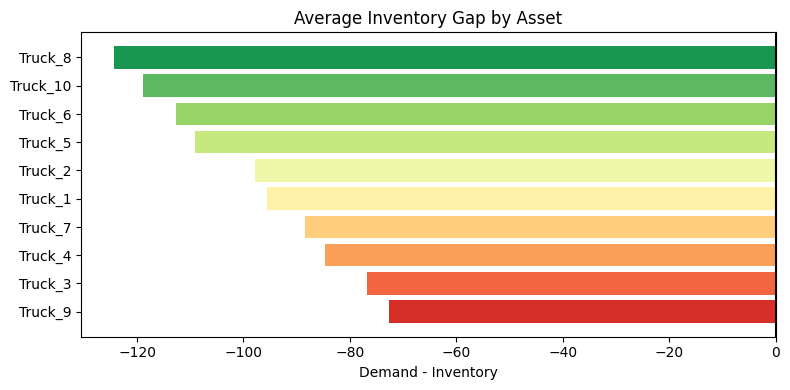

In [33]:
x=df.groupby('Asset_ID')['Inventory_Gap'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.barh(x.index,x.values,color=plt.cm.RdYlGn(np.linspace(.1,.9,len(x))))
plt.axvline(0,color='black')
plt.xlabel('Demand - Inventory')
plt.title('Average Inventory Gap by Asset')
plt.tight_layout()

**Insight:** Truck_9 has the largest average demand-over-inventory gap.

**Business Improvement:** Prioritize replenishment for assets with persistent positive gaps.

## Where does forecast demand exceed inventory?

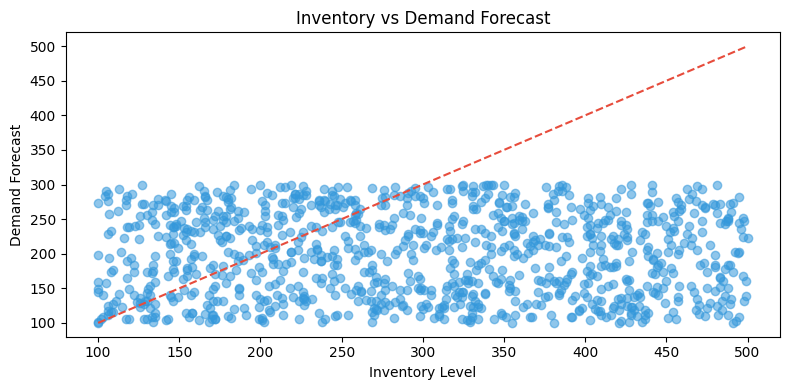

In [34]:
plt.figure(figsize=(8,4))
plt.scatter(df['Inventory_Level'],df['Demand_Forecast'],alpha=.55,color='#3498DB')
plt.plot([100,500],[100,500],'--',color='#E74C3C')
plt.xlabel('Inventory Level')
plt.ylabel('Demand Forecast')
plt.title('Inventory vs Demand Forecast')
plt.tight_layout()

**Insight:** Points above the diagonal represent demand-over-inventory risk.

**Business Improvement:** Trigger replenishment before positive gaps become service failures.

## Which inventory status contributes more revenue?

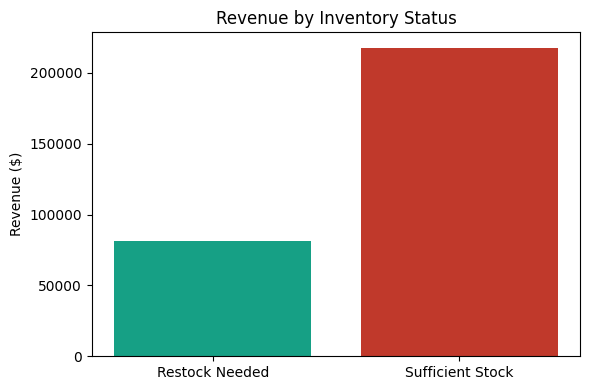

In [35]:
x=df.groupby('Inventory_Status')['User_Transaction_Amount'].sum()
plt.figure(figsize=(6,4))
plt.bar(x.index,x.values,color=['#16A085','#C0392B'])
plt.ylabel('Revenue ($)')
plt.title('Revenue by Inventory Status')
plt.tight_layout()

**Insight:** Sufficient Stock records contribute $217,746.

**Business Improvement:** Protect revenue in restock-needed operations by closing inventory gaps early.

## Which traffic condition has the highest utilization?

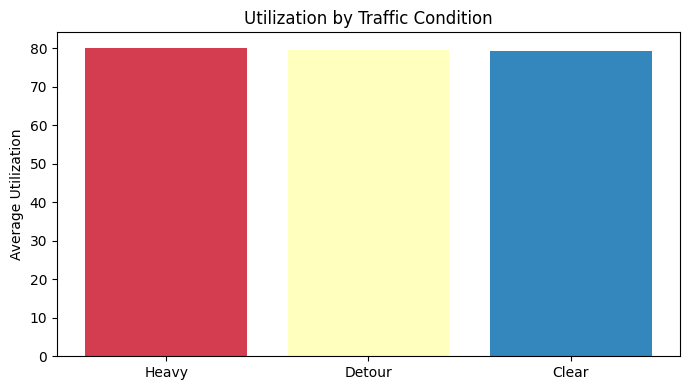

In [36]:
x=df.groupby('Traffic_Status')['Asset_Utilization'].mean().sort_values(ascending=False)
plt.figure(figsize=(7,4))
plt.bar(x.index,x.values,color=plt.cm.Spectral(np.linspace(.1,.9,len(x))))
plt.ylabel('Average Utilization')
plt.title('Utilization by Traffic Condition')
plt.tight_layout()

**Insight:** Heavy has the highest utilization at 80.13.

**Business Improvement:** Ensure recovery capacity and maintenance coverage are available under that condition.

## Which delay reason has the longest wait?

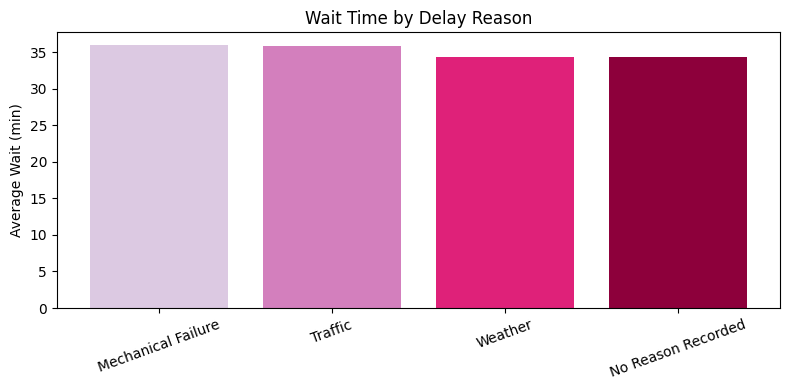

In [37]:
x=df.groupby('Logistics_Delay_Reason')['Waiting_Time'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.bar(x.index,x.values,color=plt.cm.PuRd(np.linspace(.2,.9,len(x))))
plt.ylabel('Average Wait (min)')
plt.title('Wait Time by Delay Reason')
plt.xticks(rotation=20)
plt.tight_layout()

**Insight:** Truck_1 has the longest average wait at 37.02 minutes.

**Business Improvement:** Build a focused recovery playbook for the delay reason with the longest wait.

## Which delay reason occurs most often?

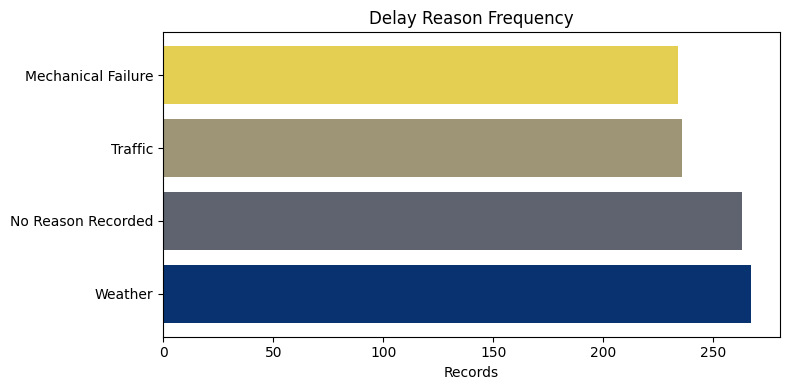

In [38]:
x=df['Logistics_Delay_Reason'].value_counts()
plt.figure(figsize=(8,4))
plt.barh(x.index,x.values,color=plt.cm.cividis(np.linspace(.1,.9,len(x))))
plt.xlabel('Records')
plt.title('Delay Reason Frequency')
plt.tight_layout()

**Insight:** Weather is the most frequent reason category with 267 records.

**Business Improvement:** Attack the dominant cause and improve root-cause logging for all delay events.

## How do delay reasons vary across traffic conditions?

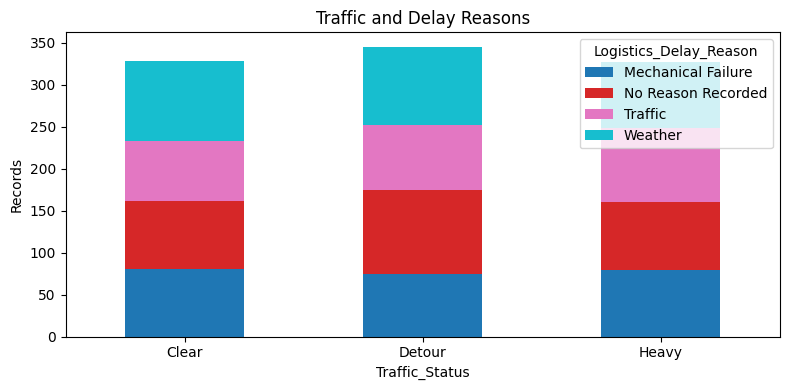

In [39]:
x=pd.crosstab(df['Traffic_Status'],df['Logistics_Delay_Reason'])
x.plot(kind='bar',stacked=True,figsize=(8,4),colormap='tab10')
plt.ylabel('Records')
plt.title('Traffic and Delay Reasons')
plt.xticks(rotation=0)
plt.tight_layout()

**Insight:** Delay causes vary by traffic condition, so one mitigation strategy will not fit every operating state.

**Business Improvement:** Use traffic-specific mitigation playbooks for routing, maintenance, and weather exposure.

## Which traffic condition has the highest delay rate?

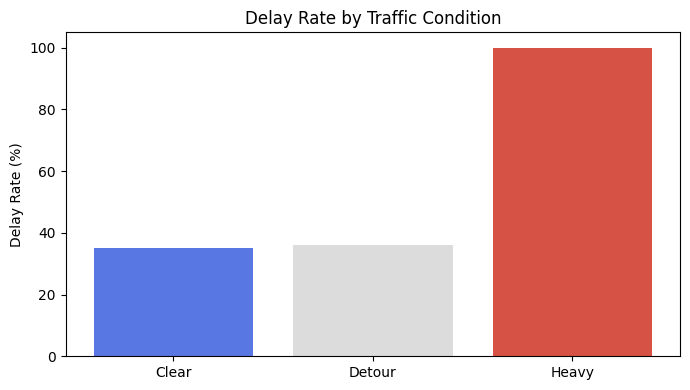

In [40]:
x=df.groupby('Traffic_Status')['Logistics_Delay'].mean()*100
plt.figure(figsize=(7,4))
plt.bar(x.index,x.values,color=plt.cm.coolwarm(np.linspace(.1,.9,len(x))))
plt.ylabel('Delay Rate (%)')
plt.title('Delay Rate by Traffic Condition')
plt.tight_layout()

**Insight:** Heavy has the highest delay rate at 100.0%.

**Business Improvement:** Add congestion buffers and route alternatives for the highest-risk traffic state.

## Which delay reason has the highest average transaction exposure?

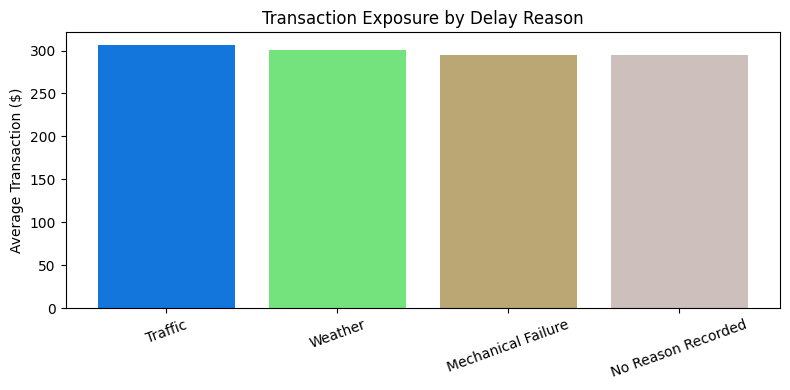

In [41]:
x=df.groupby('Logistics_Delay_Reason')['User_Transaction_Amount'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.bar(x.index,x.values,color=plt.cm.terrain(np.linspace(.1,.9,len(x))))
plt.ylabel('Average Transaction ($)')
plt.title('Transaction Exposure by Delay Reason')
plt.xticks(rotation=20)
plt.tight_layout()

**Insight:** Traffic carries the highest average transaction exposure at $305.88 per record.

**Business Improvement:** Prioritize controls where delays threaten higher-value transactions.

## Does temperature differ between delayed and non-delayed trips?

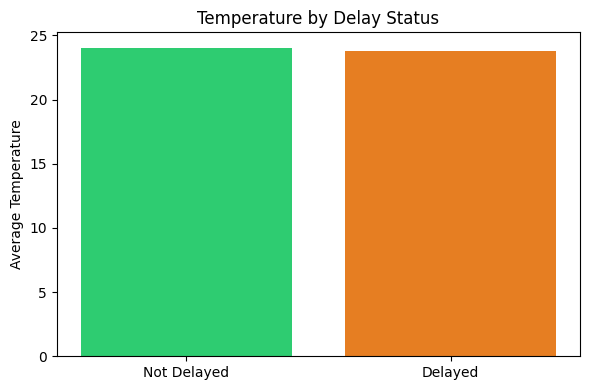

In [42]:
x=df.groupby('Logistics_Delay')['Temperature'].mean()
plt.figure(figsize=(6,4))
plt.bar(['Not Delayed','Delayed'],[x.get(0,0),x.get(1,0)],color=['#2ECC71','#E67E22'])
plt.ylabel('Average Temperature')
plt.title('Temperature by Delay Status')
plt.tight_layout()

**Insight:** Delayed trips average 23.78° while non-delayed trips average 24.04°.

**Business Improvement:** Treat temperature as a supporting risk signal and combine it with operational factors.

## Does humidity differ between delayed and non-delayed trips?

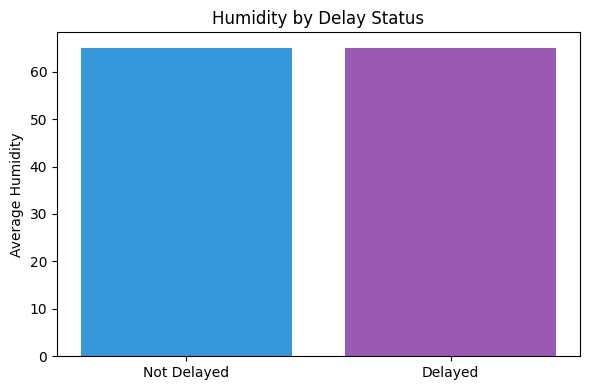

In [43]:
x=df.groupby('Logistics_Delay')['Humidity'].mean()
plt.figure(figsize=(6,4))
plt.bar(['Not Delayed','Delayed'],[x.get(0,0),x.get(1,0)],color=['#3498DB','#9B59B6'])
plt.ylabel('Average Humidity')
plt.title('Humidity by Delay Status')
plt.tight_layout()

**Insight:** Delayed trips average 65.04% humidity versus 65.05% for non-delayed trips.

**Business Improvement:** Use environmental thresholds as alerts, not as standalone delay decisions.

## Which months combine high revenue and high delay exposure?

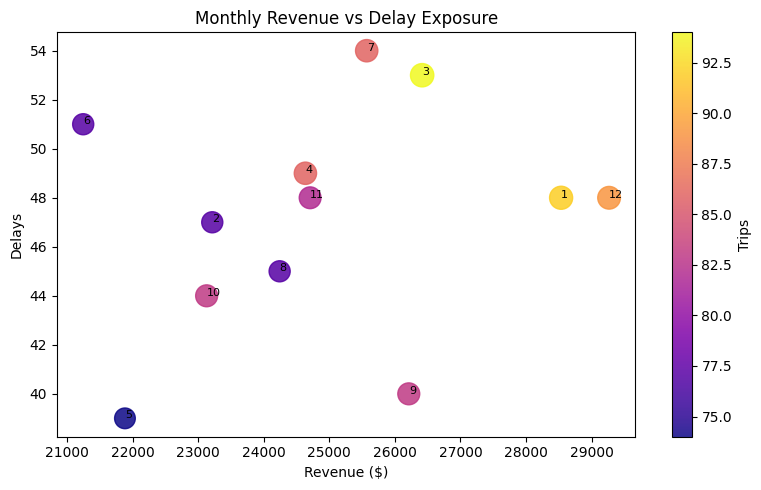

In [44]:
x=df.groupby('Month').agg(revenue=('User_Transaction_Amount','sum'),delays=('Logistics_Delay','sum'),trips=('Asset_ID','size'))
plt.figure(figsize=(8,5))
plt.scatter(x.revenue,x.delays,s=x.trips*3,c=x.trips,cmap='plasma',alpha=.85)
for m,r in x.iterrows(): plt.text(r.revenue,r.delays,str(m),fontsize=8)
plt.xlabel('Revenue ($)')
plt.ylabel('Delays')
plt.title('Monthly Revenue vs Delay Exposure')
plt.colorbar(label='Trips')
plt.tight_layout()

**Insight:** The months with both high revenue and high delays represent the greatest business exposure.

**Business Improvement:** Add capacity and exception management to high-revenue/high-delay periods.

## Which hour has the highest trip volume?

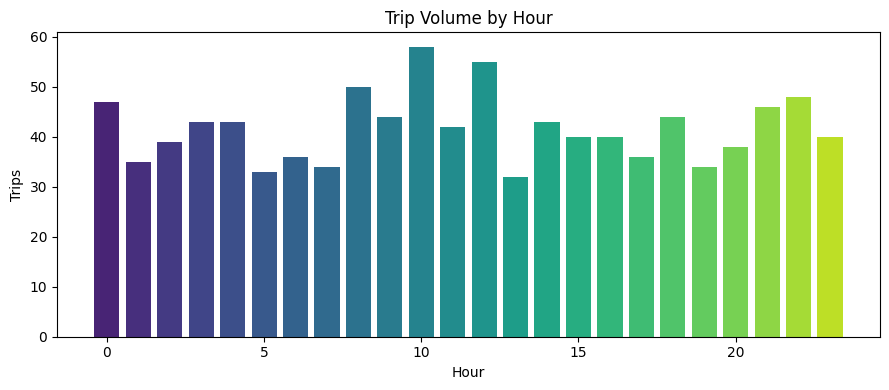

In [45]:
x=df.groupby('Hour').size()
plt.figure(figsize=(9,4))
plt.bar(x.index,x.values,color=plt.cm.viridis(np.linspace(.1,.9,24)))
plt.xlabel('Hour')
plt.ylabel('Trips')
plt.title('Trip Volume by Hour')
plt.tight_layout()

**Insight:** Hour 10:00 has the highest trip volume with 58 trips.

**Business Improvement:** Align staffing and asset availability with peak operating hours.

## Which hour has the highest delay rate?

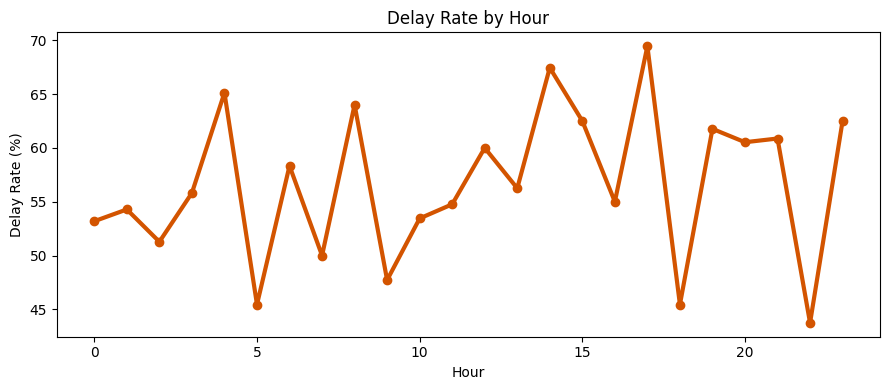

In [46]:
x=df.groupby('Hour')['Logistics_Delay'].mean()*100
plt.figure(figsize=(9,4))
plt.plot(x.index,x.values,marker='o',color='#D35400',linewidth=3)
plt.xlabel('Hour')
plt.ylabel('Delay Rate (%)')
plt.title('Delay Rate by Hour')
plt.tight_layout()

**Insight:** Hour 17:00 has the highest delay rate at 69.4%.

**Business Improvement:** Add targeted monitoring and dispatch buffers during the highest-risk hour.

## Which weekday generates the most revenue?

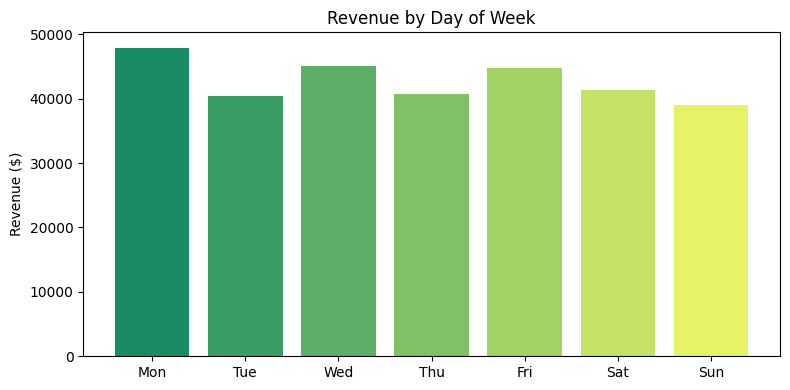

In [47]:
order=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
x=df.groupby('Weekday')['User_Transaction_Amount'].sum().reindex(order)
plt.figure(figsize=(8,4))
plt.bar(x.index,x.values,color=plt.cm.summer(np.linspace(.1,.9,7)))
plt.ylabel('Revenue ($)')
plt.title('Revenue by Day of Week')
plt.tight_layout()

**Insight:** Mon generates the most revenue at $47,895.

**Business Improvement:** Protect capacity on high-revenue days to avoid revenue leakage from service failures.

## Which assets combine high utilization with high delay volume?

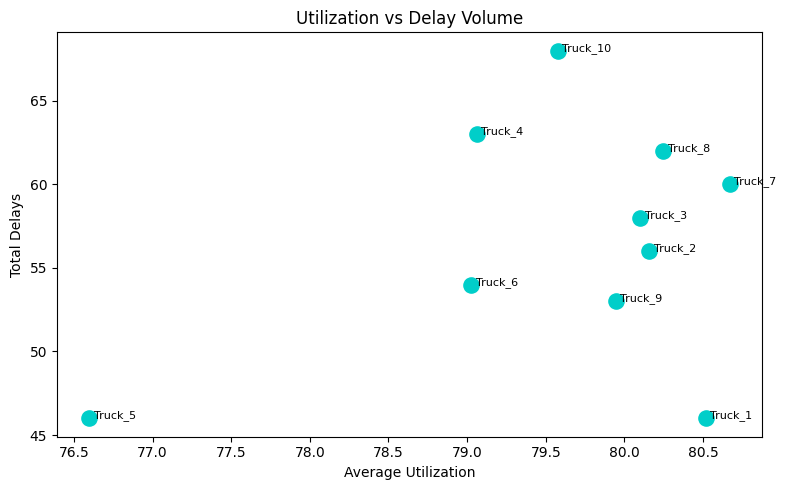

In [48]:
x=df.groupby('Asset_ID').agg(util=('Asset_Utilization','mean'),delays=('Logistics_Delay','sum'))
plt.figure(figsize=(8,5))
plt.scatter(x.util,x.delays,s=120,color='#00CEC9')
for a,r in x.iterrows(): plt.text(r.util+.03,r.delays,a,fontsize=8)
plt.xlabel('Average Utilization')
plt.ylabel('Total Delays')
plt.title('Utilization vs Delay Volume')
plt.tight_layout()

**Insight:** Assets that are both highly utilized and frequently delayed are the strongest workload-risk candidates.

**Business Improvement:** Rebalance workload and maintenance on high-utilization/high-delay assets.

## Which assets carry the highest average transaction value?

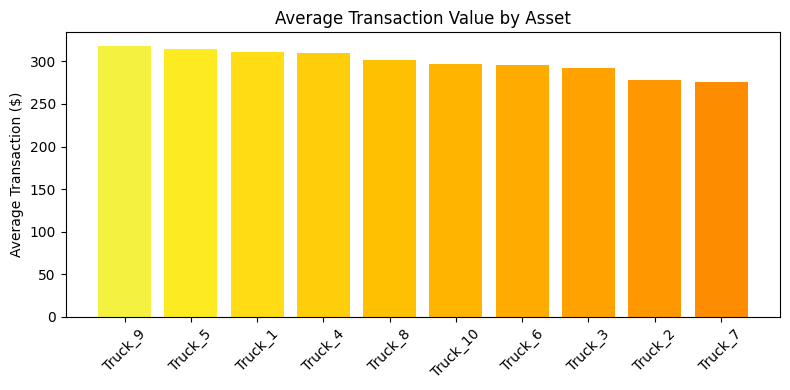

In [49]:
x=df.groupby('Asset_ID')['User_Transaction_Amount'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.bar(x.index,x.values,color=plt.cm.Wistia(np.linspace(.15,.9,len(x))))
plt.ylabel('Average Transaction ($)')
plt.title('Average Transaction Value by Asset')
plt.xticks(rotation=45)
plt.tight_layout()

**Insight:** Truck_9 carries the highest average transaction value at $318.23.

**Business Improvement:** Apply stronger service controls to assets carrying higher-value transactions.

## Which assets have the longest average wait?

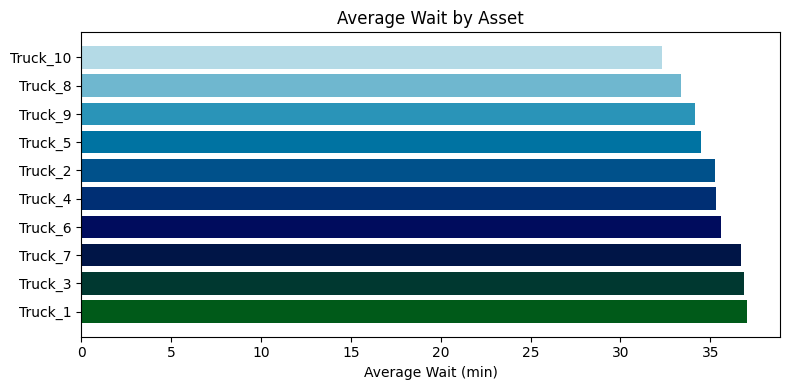

In [50]:
x=df.groupby('Asset_ID')['Waiting_Time'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.barh(x.index,x.values,color=plt.cm.ocean(np.linspace(.1,.9,len(x))))
plt.xlabel('Average Wait (min)')
plt.title('Average Wait by Asset')
plt.tight_layout()

**Insight:** Truck_1 has the longest average wait at 37.02 minutes.

**Business Improvement:** Investigate loading, route, and dispatch causes for the highest-wait asset.

## Which assets are below the overall utilization benchmark?

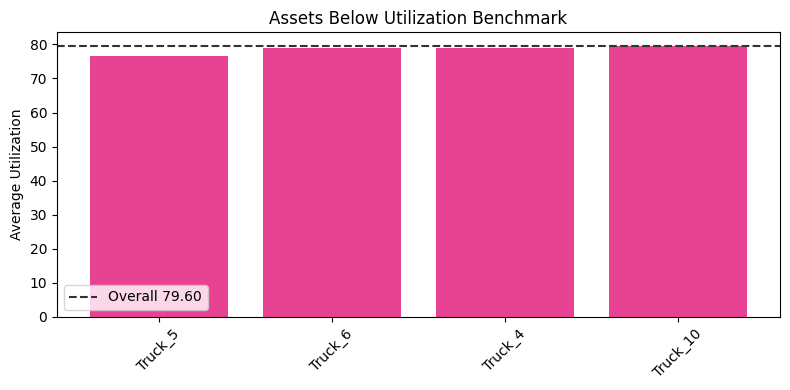

In [51]:
overall=df['Asset_Utilization'].mean()
x=df.groupby('Asset_ID')['Asset_Utilization'].mean().sort_values()
x=x[x<overall]
plt.figure(figsize=(8,4))
plt.bar(x.index,x.values,color='#E84393')
plt.axhline(overall,color='#2D3436',linestyle='--',label=f'Overall {overall:.2f}')
plt.ylabel('Average Utilization')
plt.title('Assets Below Utilization Benchmark')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

**Insight:** 4 assets are below the overall utilization average of 79.60.

**Business Improvement:** Review idle time and route allocation before adding new fleet capacity.

## Which assets face the highest demand forecast?

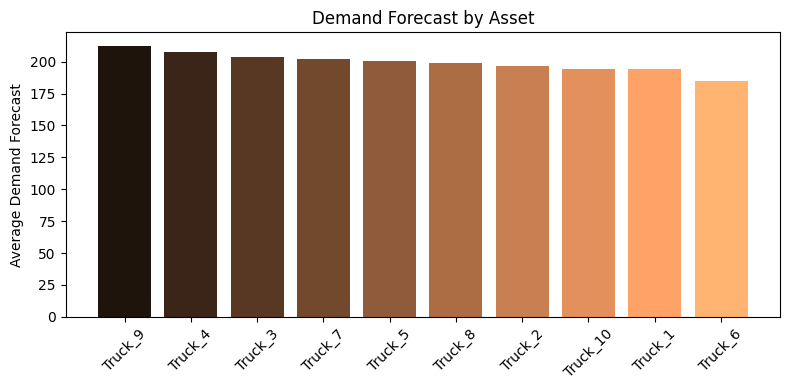

In [52]:
x=df.groupby('Asset_ID')['Demand_Forecast'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.bar(x.index,x.values,color=plt.cm.copper(np.linspace(.1,.9,len(x))))
plt.ylabel('Average Demand Forecast')
plt.title('Demand Forecast by Asset')
plt.xticks(rotation=45)
plt.tight_layout()

**Insight:** Truck_9 has the highest average demand forecast at 212.34.

**Business Improvement:** Match fleet and inventory capacity to assets facing the highest forecast demand.

## Which assets have the largest demand-over-inventory gap?

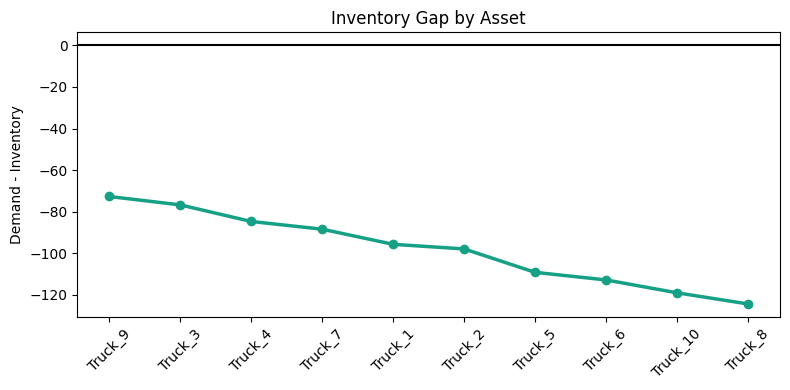

In [53]:
x=df.groupby('Asset_ID')['Inventory_Gap'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.plot(x.index,x.values,marker='o',color='#16A085',linewidth=2.5)
plt.axhline(0,color='black')
plt.ylabel('Demand - Inventory')
plt.title('Inventory Gap by Asset')
plt.xticks(rotation=45)
plt.tight_layout()

**Insight:** Truck_9 has the largest positive inventory gap at -72.67.

**Business Improvement:** Prioritize replenishment for assets with persistent positive gaps.

## Does inventory status affect delay rate?

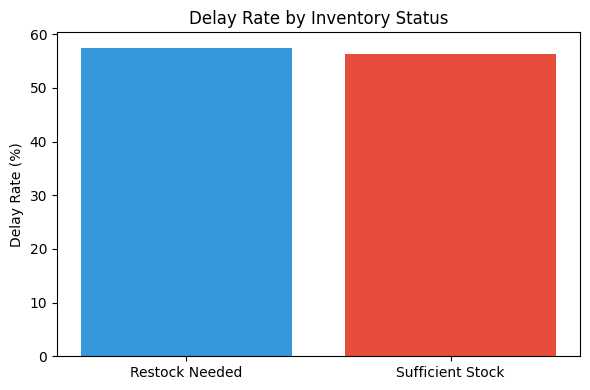

In [54]:
x=df.groupby('Inventory_Status')['Logistics_Delay'].mean()*100
plt.figure(figsize=(6,4))
plt.bar(x.index,x.values,color=['#3498DB','#E74C3C'])
plt.ylabel('Delay Rate (%)')
plt.title('Delay Rate by Inventory Status')
plt.tight_layout()

**Insight:** Restock Needed has the higher delay rate at 57.5%.

**Business Improvement:** Combine replenishment alerts with delivery monitoring where stock risk is higher.

## Which shipment status has the highest average transaction value?

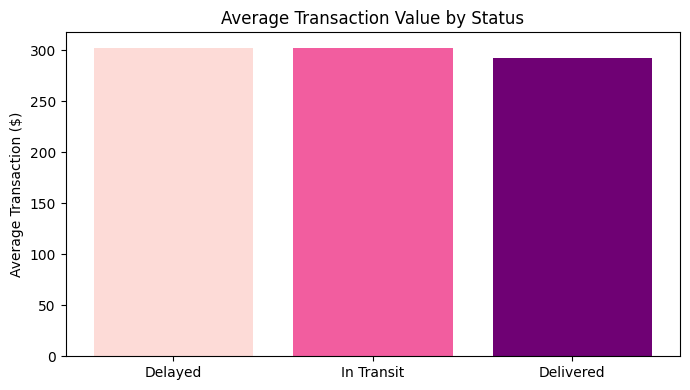

In [55]:
x=df.groupby('Shipment_Status')['User_Transaction_Amount'].mean().sort_values(ascending=False)
plt.figure(figsize=(7,4))
plt.bar(x.index,x.values,color=plt.cm.RdPu(np.linspace(.15,.9,len(x))))
plt.ylabel('Average Transaction ($)')
plt.title('Average Transaction Value by Status')
plt.tight_layout()

**Insight:** Delayed has the highest average transaction value at $302.51.

**Business Improvement:** Give the highest-value shipment stage stronger exception handling.

## Does waiting time concentrate around certain transaction values?

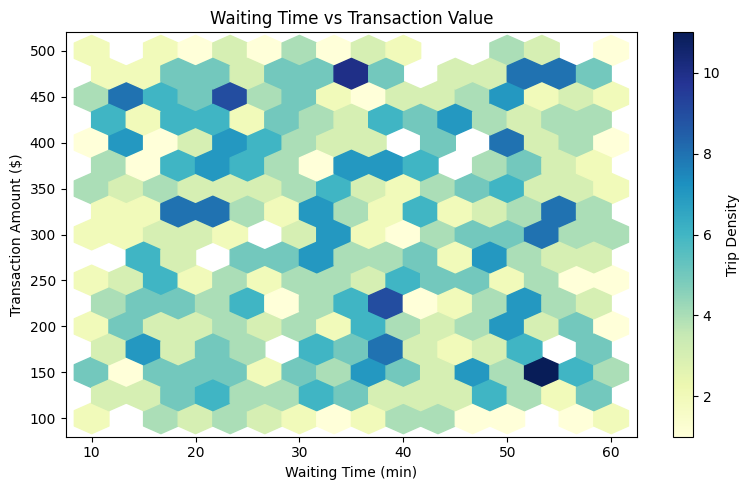

In [56]:
plt.figure(figsize=(8,5))
plt.hexbin(df['Waiting_Time'],df['User_Transaction_Amount'],gridsize=15,cmap='YlGnBu',mincnt=1)
plt.xlabel('Waiting Time (min)')
plt.ylabel('Transaction Amount ($)')
plt.title('Waiting Time vs Transaction Value')
plt.colorbar(label='Trip Density')
plt.tight_layout()

**Insight:** High-value transactions occur across multiple waiting-time levels, so wait alone does not explain transaction value.

**Business Improvement:** Combine customer value and operational risk when setting service priorities.

## Which traffic condition has the highest revenue per trip?

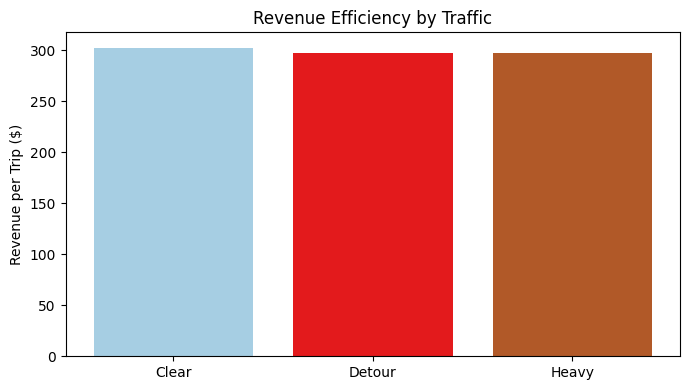

In [57]:
x=df.groupby('Traffic_Status').agg(revenue=('User_Transaction_Amount','sum'),trips=('Asset_ID','size'))
x['Revenue_Per_Trip']=x.revenue/x.trips
plt.figure(figsize=(7,4))
plt.bar(x.index,x.Revenue_Per_Trip,color=plt.cm.Paired(np.linspace(.05,.95,len(x))))
plt.ylabel('Revenue per Trip ($)')
plt.title('Revenue Efficiency by Traffic')
plt.tight_layout()

**Insight:** Clear has the highest revenue per trip.

**Business Improvement:** Preserve service quality in high-yield traffic conditions while reducing disruption.

## Which month has the highest average waiting time?

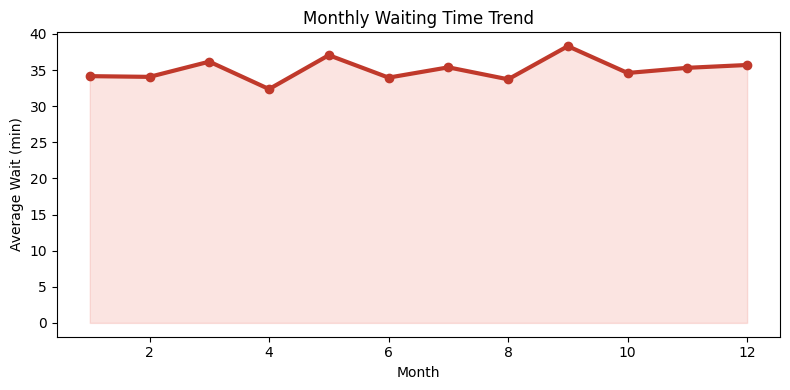

In [58]:
x=df.groupby('Month')['Waiting_Time'].mean()
plt.figure(figsize=(8,4))
plt.plot(x.index,x.values,marker='o',color='#C0392B',linewidth=3)
plt.fill_between(x.index,x.values,alpha=.15,color='#E74C3C')
plt.xlabel('Month')
plt.ylabel('Average Wait (min)')
plt.title('Monthly Waiting Time Trend')
plt.tight_layout()

**Insight:** Month 9 has the highest average wait at 38.30 minutes.

**Business Improvement:** Investigate the causes of the highest-wait month and plan buffers ahead of it.

## Which month has the highest average asset utilization?

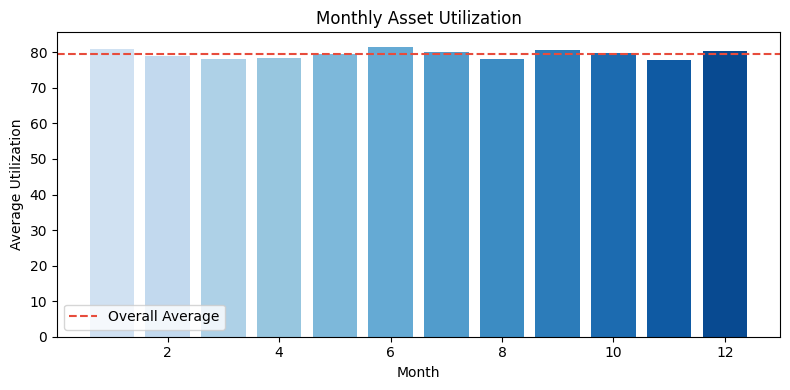

In [59]:
x=df.groupby('Month')['Asset_Utilization'].mean()
plt.figure(figsize=(8,4))
plt.bar(x.index,x.values,color=plt.cm.Blues(np.linspace(.2,.9,12)))
plt.axhline(df['Asset_Utilization'].mean(),color='#E74C3C',linestyle='--',label='Overall Average')
plt.xlabel('Month')
plt.ylabel('Average Utilization')
plt.title('Monthly Asset Utilization')
plt.legend()
plt.tight_layout()

**Insight:** Month 6 has the highest utilization at 81.55.

**Business Improvement:** Schedule maintenance before high-utilization periods create capacity failures.

## Which numeric factors are most associated with logistics delays?

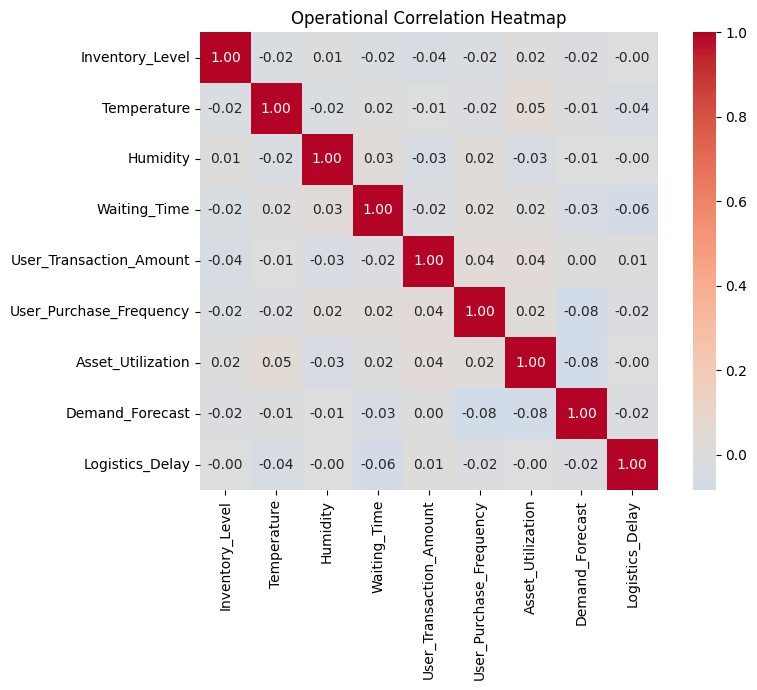

In [60]:
cols=['Inventory_Level','Temperature','Humidity','Waiting_Time','User_Transaction_Amount','User_Purchase_Frequency','Asset_Utilization','Demand_Forecast','Logistics_Delay']
corr=df[cols].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0,square=True)
plt.title('Operational Correlation Heatmap')
plt.tight_layout()

**Insight:** Waiting time has the strongest absolute numeric correlation with the delay flag, but the relationship remains weak.

**Business Improvement:** Use correlations as signals for deeper root-cause analysis, not as single-factor decisions.

## What should management prioritize first?

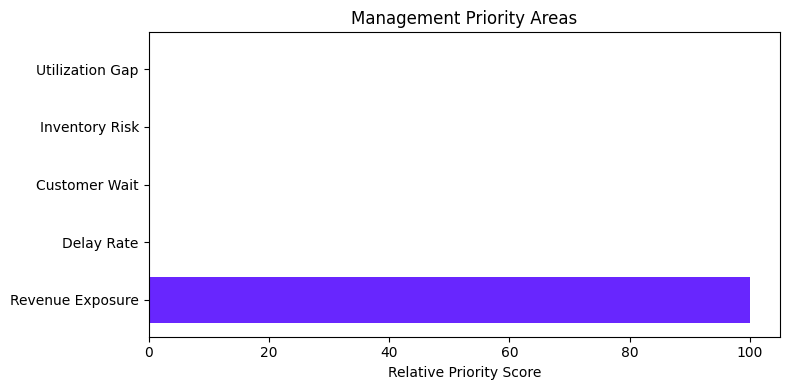

In [61]:
priority=pd.DataFrame({'Area':['Delay Rate','Customer Wait','Inventory Risk','Utilization Gap','Revenue Exposure'],'Score':[df.Logistics_Delay.mean()*100,df.loc[df.Logistics_Delay==1,'Waiting_Time'].mean(),(df.Inventory_Gap>0).mean()*100,85-df.Asset_Utilization.mean(),df.groupby('Logistics_Delay_Reason')['User_Transaction_Amount'].sum().max()]})
priority['Score']=priority['Score']/priority['Score'].max()*100
priority=priority.sort_values('Score',ascending=False)
plt.figure(figsize=(8,4))
plt.barh(priority.Area,priority.Score,color=plt.cm.rainbow(np.linspace(.05,.95,len(priority))))
plt.xlabel('Relative Priority Score')
plt.title('Management Priority Areas')
plt.tight_layout()

**Insight:** The largest management exposures are delays, customer waiting, inventory gaps, utilization performance, and revenue at risk.

**Business Improvement:** Reduce delays first, protect high-value revenue, close inventory gaps, and improve utilization without increasing operational risk.